In [2]:
import matplotlib.pyplot as plt
import random as rd
import numpy as np
import scipy
from math import *
from scipy.optimize import curve_fit
import os

In [3]:
folder_name = 'data_2025'
folder_path = os.path.abspath(os.path.join(os.getcwd(), '..',folder_name))


In [4]:
def linear(x, a, b) : # Fonction liénaire pour la calibration canal-nanoseconde
    return a * x + b

def f(theta) : ## Fonction cos(theta)**2 pour estimer la distance moyenne parcourue par les muons
    return (np.cos(theta))**2

def gaussian(x, a, mu, sigma) : # Fonction gaussienne pour déterminer le temps moyen de parcours des muons
    return a*np.exp(-1/2*(x - mu)**2/sigma**2)

def open_file(position,folder=folder_path) : # Fcontion ouvrant le fichier contenant l'acquisition expérimentale
    file = "spectre_position_" + position + ".txt"
    path= os.path.join(folder, file)
    file = open(path, "r")
    data = file.readlines()
    file.close()
    data = [data[i].split("\n") for i in range(65536)]
    data = [int(data[i][0]) for i in range(65536)]
    return data

def calibration(time, channel) : # Calibration temporelle de la chaine d'acquisition : canal vers nanoseconde

    par, cov = scipy.optimize.curve_fit(linear, channel, time) # Ajustement linéaire

    a, b = par[0], par[1] # Coefficient directeur et ordonnée à l'origine
    err_a, err_b = np.sqrt(cov[0][0]), np.sqrt(cov[1][1]) # Erreur sur les paramètres d'ajustement
    
    return a, b, err_a, err_b

def average_distance(position) : # Fonction calculant la distance moyenne selon la position

    if position == 'basse' or position == 'Basse': 
        d = 0.41
        xmax = 0.20
        ymax = 1.00

    elif position == 'haute' or position =='Haute' :
        d= 1.17
        xmax = 0.20
        ymax = 1.00

    ## Simulation de la distance moyenne

    Ld = [] ## Liste des résultats pour la distance             
    Lt = [] ## Liste des résultats pour théta 

    N = 100000 ## Nombre d'évenements

    for i in range(N) :
        x1 = rd.uniform(0, xmax)
        y1 = rd.uniform(0, ymax)
        phi = rd.uniform(0, 2*np.pi)
        theta = rd.uniform(-np.pi/2, np.pi/2)
        b = rd.uniform(0, 1)
        if f(theta) >= b: # Masque 
            Lt.append(theta)
            a = d*np.tan(theta)
            x2 = x1+a*np.sin(phi)
            y2 = y1 + a*np.cos(phi)
            if 0 < x2 < xmax and 0 < y2 < ymax :
                Ld.append(d*np.sqrt(1 + (np.tan(theta))**2))
                
    return np.mean(Ld)

def time_average(position, time, channel) : # Fonction calculant le temps moyen selon la position
    
    adujstment = calibration(time, channel)
    N = np.array(open_file(position))
    T = adujstment[0] * np.linspace(0, len(N), len(N)) + adujstment[1]

    par, cov = scipy.optimize.curve_fit(gaussian, T, N, bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))

    C, mu, sigma = par[0], par[1], par[2]
    err_C, err_mu, err_sigma = np.sqrt(cov[0][0]), np.sqrt(cov[1][1]), np.sqrt(cov[2][2])

    return C, mu, sigma, err_C, err_mu, err_sigma, N, T

def velocity(time, channel) : # Fonction calculant la vitesse moyenne des muons
    
    v = (average_distance("haute") - average_distance("basse")) / np.abs(time_average("haute", time, channel)[1] - time_average("basse", time, channel)[1]) * 10**9
    
    return v 

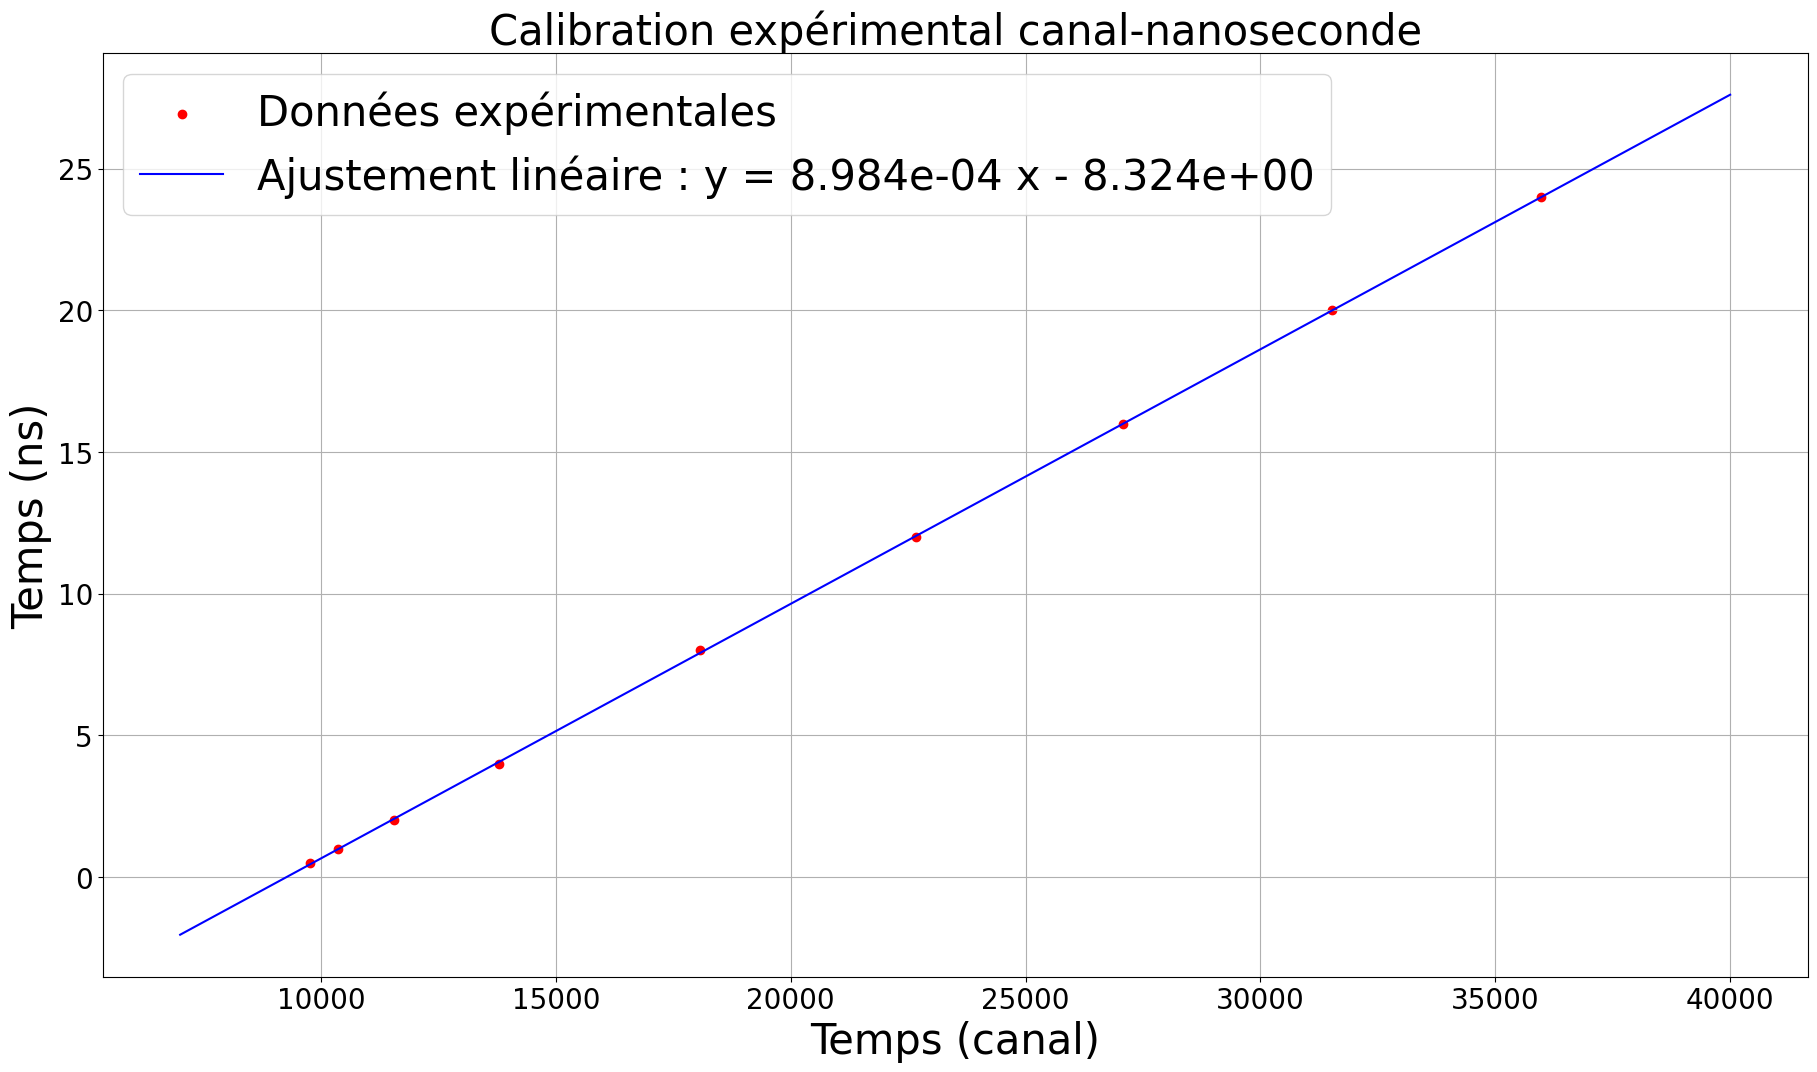

---------- Paramètres pour la calibration ----------
              a = 8.98e-04 +/- 1.84e-06
              b = -8.32e+00 +/- 4.06e-02
----------------------------------------------------


In [5]:
# Calibration temporelle de la chaine d'acquisition : canal vers nanoseconde

channel = [9769, 10365, 11545, 13792, 18075, 22665, 27070, 31525, 35980] # Données en canaux
time = [0.5, 1, 2, 4, 8, 12, 16, 20, 24] # Données en temps

adujstment = calibration(time, channel)

plt.figure(figsize = (22, 12))
plt.scatter(channel, time, color = "red", label = "Données expérimentales")
plt.plot(np.linspace(7000, 40000), adujstment[0]*np.linspace(7000, 40000)+adujstment[1], color = "blue", label = r'Ajustement linéaire : y = {:.3e} x - {:.3e}'.format(adujstment[0], np.abs(adujstment[1])))
plt.xlabel("Temps (canal)", fontsize=30)
plt.ylabel("Temps (ns)", fontsize=30)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
plt.title(r'Calibration expérimental canal-nanoseconde', fontsize = 30)
plt.legend(loc = "best", fontsize = 30)
plt.grid()
plt.show()

print("---------- Paramètres pour la calibration ----------")
print('              a = {:.2e} +/- {:.2e}'.format(adujstment[0], adujstment[2]))
print('              b = {:.2e} +/- {:.2e}'.format(adujstment[1], adujstment[3]))
print("----------------------------------------------------")

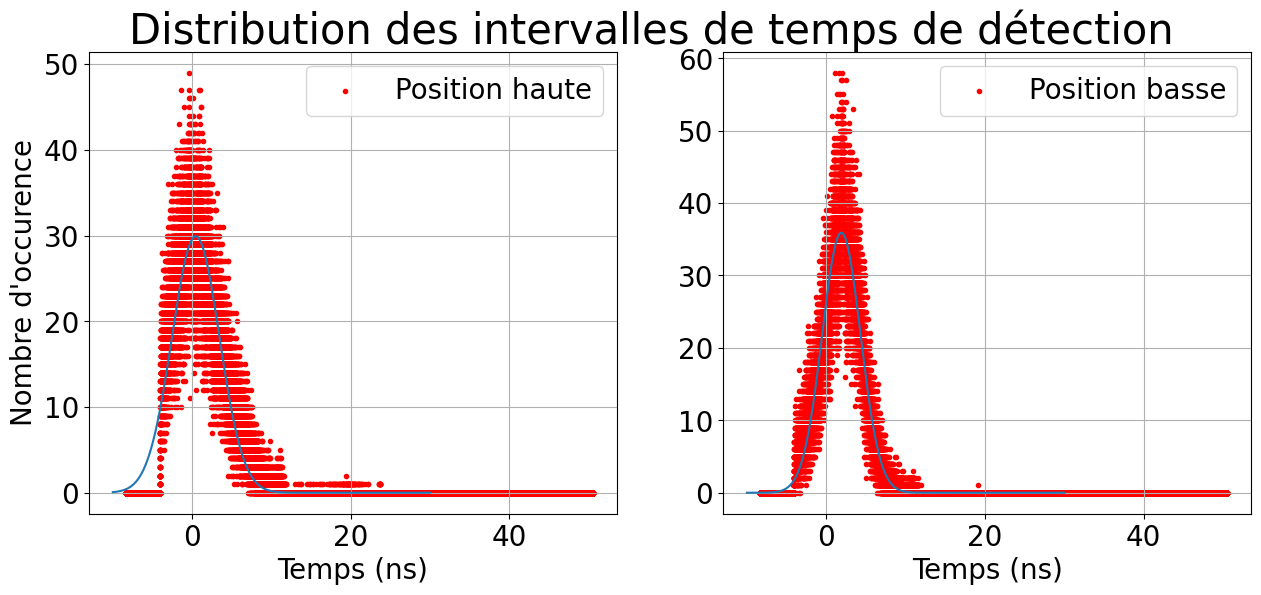

In [6]:
# Figures donnant le temps moyen de parcours en fonction de la position

data_up = time_average("haute", time, channel)
data_low = time_average("basse", time, channel)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))  

axs[0].scatter(data_up[7], data_up[6], color = 'red', marker = '.', label = "Position haute")
axs[0].plot(np.linspace(-10, 30, 1000), gaussian(np.linspace(-10, 30, 1000), data_up[0], data_up[1], data_up[2]))
axs[0].set_xlabel("Temps (ns)", fontsize = 20)
axs[0].set_ylabel("Nombre d'occurence", fontsize = 20)
axs[0].tick_params(axis='x', labelsize=20)
axs[0].tick_params(axis='y', labelsize=20)
axs[0].grid()
axs[0].legend(loc="best", fontsize = 20)

axs[1].scatter(data_low[7], data_low[6], color = 'red', marker = '.', label = "Position basse")
axs[1].plot(np.linspace(-10, 30, 1000), gaussian(np.linspace(-10, 30, 1000), data_low[0], data_low[1], data_low[2]))
axs[1].set_xlabel("Temps (ns)", fontsize = 20)
axs[1].tick_params(axis='x', labelsize=20)
axs[1].tick_params(axis='y', labelsize=20)
axs[1].grid()
axs[1].legend(loc="best", fontsize = 20)

fig.suptitle("Distribution des intervalles de temps de détection", fontsize = 30, ha = 'center', y = 0.95)
plt.show()

In [7]:
# Détermination de la vitesse moyenne des muons

V = velocity(time, channel)

print("Vitesse moyenne des muons : " + str(int(V)) + " m/s")
print("Soit V  = " + str(np.round(V/299792458, 2)) + " c")

Vitesse moyenne des muons : 518952116 m/s
Soit V  = 1.73 c


In [8]:
# Erreurs sur les temps et les distances moyennes en utilisant les données des séances 2 et 3

t_up = data_up[1]
delta_t_up = data_up[2]/np.sqrt(np.sum(data_up[6]))
print("t_up = (" + str(np.round(t_up, 3)) + " +/- " + str(np.round(delta_t_up, 3)) + ") ns")

t_low = data_low[1]
delta_t_low = data_low[2]/np.sqrt(np.sum(data_low[6]))
print("t_low = (" + str(np.round(t_low, 3)) + " +/- " + str(np.round(delta_t_low, 3)) + ") ns")

d_up = 1.189
delta_d_up = 0.026 
print("d_up = (" + str(d_up) + " +/- " + str(delta_d_up) + ") m")

d_low = 0.434
delta_d_low = 0.022 
print("d_low = (" + str(d_low) + " +/- " + str(delta_d_low) + ") m")

t_up = (0.45 +/- 0.006) ns
t_low = (1.907 +/- 0.005) ns
d_up = (1.189 +/- 0.026) m
d_low = (0.434 +/- 0.022) m


In [9]:
# Erreur sur la vitesse moyenne des muons

delta_V = V * np.sqrt((delta_t_up/t_up)**2 + (delta_t_low/t_low)**2 + (delta_d_up/d_up)**2 + (delta_d_low/d_low)**2)
print("V = (" + str(np.round(V/10**8, 3)) + " +/- " + str(np.round(delta_V/10**8, 3)) + ") x  10^8 m/s")
print("Soit ΔV/V = " + str(np.round(delta_V/V * 100, 3)) + " %")

V = (5.19 +/- 0.295) x  10^8 m/s
Soit ΔV/V = 5.685 %
